In [2]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3

In [3]:
def scientific_latex(value):
    exponent = int(np.floor(np.log10(abs(value))))
    mantissa = value / 10**exponent
    return rf"${mantissa:.1f}\times10^{{{exponent}}}$"

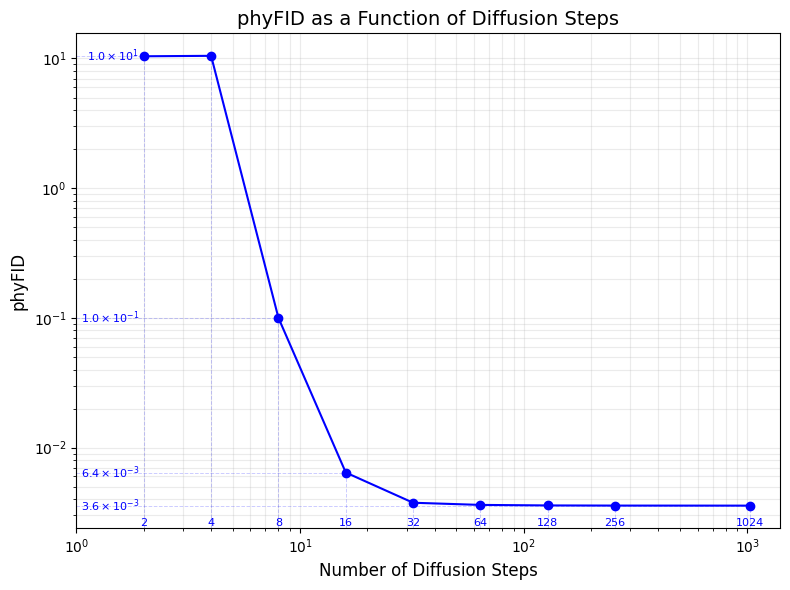

In [4]:
FID_f_STEPS = "FID_fonction_de_STEPS_data_vrai.csv"

data = np.loadtxt(FID_f_STEPS, delimiter=",", skiprows=1)
steps = data[:, 0]
fid_values = data[:, 1]

fig, ax = plt.subplots(figsize=(8, 6))

color = "b"

ax.plot(
    steps,
    fid_values,
    marker="o",
    linestyle="-",
    color=color
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Number of Diffusion Steps", fontsize=12)
ax.set_ylabel("phyFID", fontsize=12)
ax.set_title("phyFID as a Function of Diffusion Steps", fontsize=14)

ax.set_xlim(left=1)

# Limites des axes
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

min_dx_log = 0.08   # distance minimale en log10 sur x
min_dy_log = 0.08   # distance minimale en log10 sur y

annotated_x = []
annotated_y = []

for x, y in zip(steps, fid_values):

    draw_x = all(
        abs(np.log10(x) - np.log10(x_old)) > min_dx_log
        for x_old in annotated_x
    )

    if draw_x:
        ax.vlines(x, ymin, y, color=color,
                  linestyle="--", linewidth=0.7, alpha=0.2)

        ax.annotate(
            f"{x:g}",
            xy=(x, ymin),
            xytext=(0, 7),
            textcoords="offset points",
            color=color,
            fontsize=8,
            ha="center",
            va="top",
            annotation_clip=False
        )

        annotated_x.append(x)

    draw_y = all(
        abs(np.log10(y) - np.log10(y_old)) > min_dy_log
        for y_old in annotated_y
    )

    if draw_y:
        ax.hlines(y, xmin, x, color=color,
                  linestyle="--", linewidth=0.7, alpha=0.2)

        ax.annotate(
            scientific_latex(y),
            xy=(xmin, y),
            xytext=(45, 0),
            textcoords="offset points",
            color=color,
            fontsize=8,
            ha="right",
            va="center",
            annotation_clip=False
        )

        annotated_y.append(y)

ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()
plt.show()

---
## Synthèse visuelle et physique : SGM, WSGM oracle et cascade complète

Le cas oracle emploie le coarse réel et isole donc la qualité conditionnelle des niveaux de détail. La cascade complète échantillonne également le coarse ; son écart mesure l'accumulation d'erreur. Les métriques sont calculées sur 1 000 images avec le même split validation/hold-out.

In [ ]:
import sys
import torch

project_root = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "RT64").exists()
)
sys.path.insert(0, str(project_root / "analyse_reslutat"))
from result_utils import (
    compare_result_metrics,
    plot_image_grid,
    plot_spectral_energy,
    print_result_metrics,
    reconstruct_oracle_cascade,
    to_unit_interval,
)

real = torch.load(project_root / "data/RT64/processed/validation.pt", weights_only=True).float() / 255.0
real_coarse = torch.load(project_root / "data/RT64/processed/j2_validation.pt", weights_only=True).float()[:, :1]
baseline = to_unit_interval(torch.load(project_root / "outputs/generated/64dataset_e-4_s1024.pt", weights_only=True))
oracle_root = project_root / "outputs/generated/cascade_sgm_1024"
full_root = project_root / "outputs/generated/cascade_sgm_hcirc_blurpool_eps00001"
oracle_j2 = torch.load(oracle_root / "j2_generated_coefficients.pt", weights_only=True)
oracle_j1 = torch.load(oracle_root / "j1_generated_coefficients.pt", weights_only=True)
oracle = reconstruct_oracle_cascade(real_coarse, oracle_j2, oracle_j1)
full = torch.load(full_root / "generated_images.pt", weights_only=True)
encoder = project_root / "outputs/phyFID/64phyfid_encoder.pt"

results = {
    "Baseline SGM": compare_result_metrics(real, baseline, encoder),
    "WSGM oracle": compare_result_metrics(real, oracle, encoder),
    "WSGM cascade complète": compare_result_metrics(real, full, encoder),
}
for label, metrics in results.items():
    print_result_metrics(label, metrics)

plot_image_grid(baseline, n=16, cols=4, seed=16, title="Baseline SGM — images générées (4×4)")
plot_image_grid(oracle, n=16, cols=4, seed=16, title="WSGM oracle — coarse parfait (4×4)")
plot_image_grid(full, n=16, cols=4, seed=16, title="WSGM cascade complète (4×4)")
plot_spectral_energy(real[:1000], oracle[:1000], title="WSGM oracle — spectre d'énergie")
plot_spectral_energy(real[:1000], full[:1000], title="WSGM cascade complète — spectre d'énergie")